# EyeStim — validación culminatoria reproducible

Este notebook audita el subconjunto local de **EyeDentify**, compara los modelos congelados contra sus baselines, ejecuta el pipeline completo CNN→elipse sobre un participante Cambridge reservado y genera el panel visual final. No vuelve a entrenar ni utiliza participantes de prueba para seleccionar el modelo.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))

from IPython.display import Image, Markdown, display
from research.final_validation import run

results = run()
print('Validación ejecutada; resumen guardado en docs/training/final_validation_summary.json')

[Reporter] Reporte Markdown creado en: C:\Users\Eduar\AREA_PROGRAMCION\01_PROYECTOS\Eyestim\docs\training\session_example\session_report.md
[Reporter] Gráfico analítico exportado a: C:\Users\Eduar\AREA_PROGRAMCION\01_PROYECTOS\Eyestim\docs\training\session_example\attention_evolution.png


Validación ejecutada; resumen guardado en docs/training/final_validation_summary.json


## Integridad y particiones de EyeDentify

In [2]:
audit = results['eyedentify_integrity']
display(Markdown(
    f"**Auditoría:** {'APROBADA' if audit['passed'] else 'FALLIDA'} — "
    f"{audit['rows']:,} imágenes, {audit['participants']} participantes, "
    f"{audit['missing_images']} faltantes y cero solapamiento entre sujetos."
))
audit['split_summary']

**Auditoría:** APROBADA — 9,425 imágenes, 51 participantes, 0 faltantes y cero solapamiento entre sujetos.

{'train': {'frames': 6734,
  'participants': 36,
  'target_mean_mm': 2.383616992376992,
  'target_std_mm': 0.29760590171297974},
 'validation': {'frames': 1411,
  'participants': 8,
  'target_mean_mm': 2.426095956177652,
  'target_std_mm': 0.3139837249725762},
 'test': {'frames': 1280,
  'participants': 7,
  'target_mean_mm': 2.3648101098958336,
  'target_std_mm': 0.25930750629083826}}

## Prueba integral en participante no visto

In [3]:
end_to_end = results['cambridge_end_to_end_held_out']
paired = results['diameter_participant_level_comparison']
display(Markdown(
    f"El pipeline detectó **{end_to_end['detection_rate']:.0%}** de 150 frames, "
    f"con MAE de diámetro **{end_to_end['diameter_mae_px']:.3f} px** y "
    f"Spearman **{end_to_end['diameter_spearman']:.3f}**. "
    f"La CNN de diámetro superó la media constante en "
    f"**{paired['participants_where_model_beats_baseline']}/{paired['test_participants']}** sujetos, "
    f"aunque Wilcoxon p={paired['paired_wilcoxon_two_sided_p']:.6f} no permite afirmarlo como concluyente."
))
end_to_end

El pipeline detectó **100%** de 150 frames, con MAE de diámetro **0.876 px** y Spearman **0.785**. La CNN de diámetro superó la media constante en **6/7** sujetos, aunque Wilcoxon p=0.296875 no permite afirmarlo como concluyente.

{'n': 150,
 'detection_rate': 1.0,
 'cnn_center_mae_px': 5.707699577609698,
 'ellipse_center_mae_px': 1.7642661390904577,
 'diameter_mae_px': 0.8755611228942871,
 'diameter_median_ae_px': 0.7255293726921082,
 'diameter_p95_ae_px': 2.1310477137565598,
 'diameter_bias_px': -0.6812706152598064,
 'diameter_spearman': 0.7845090518102134,
 'crop_size': 32,
 'threshold_offset': 35}

## Panel visual de resultados

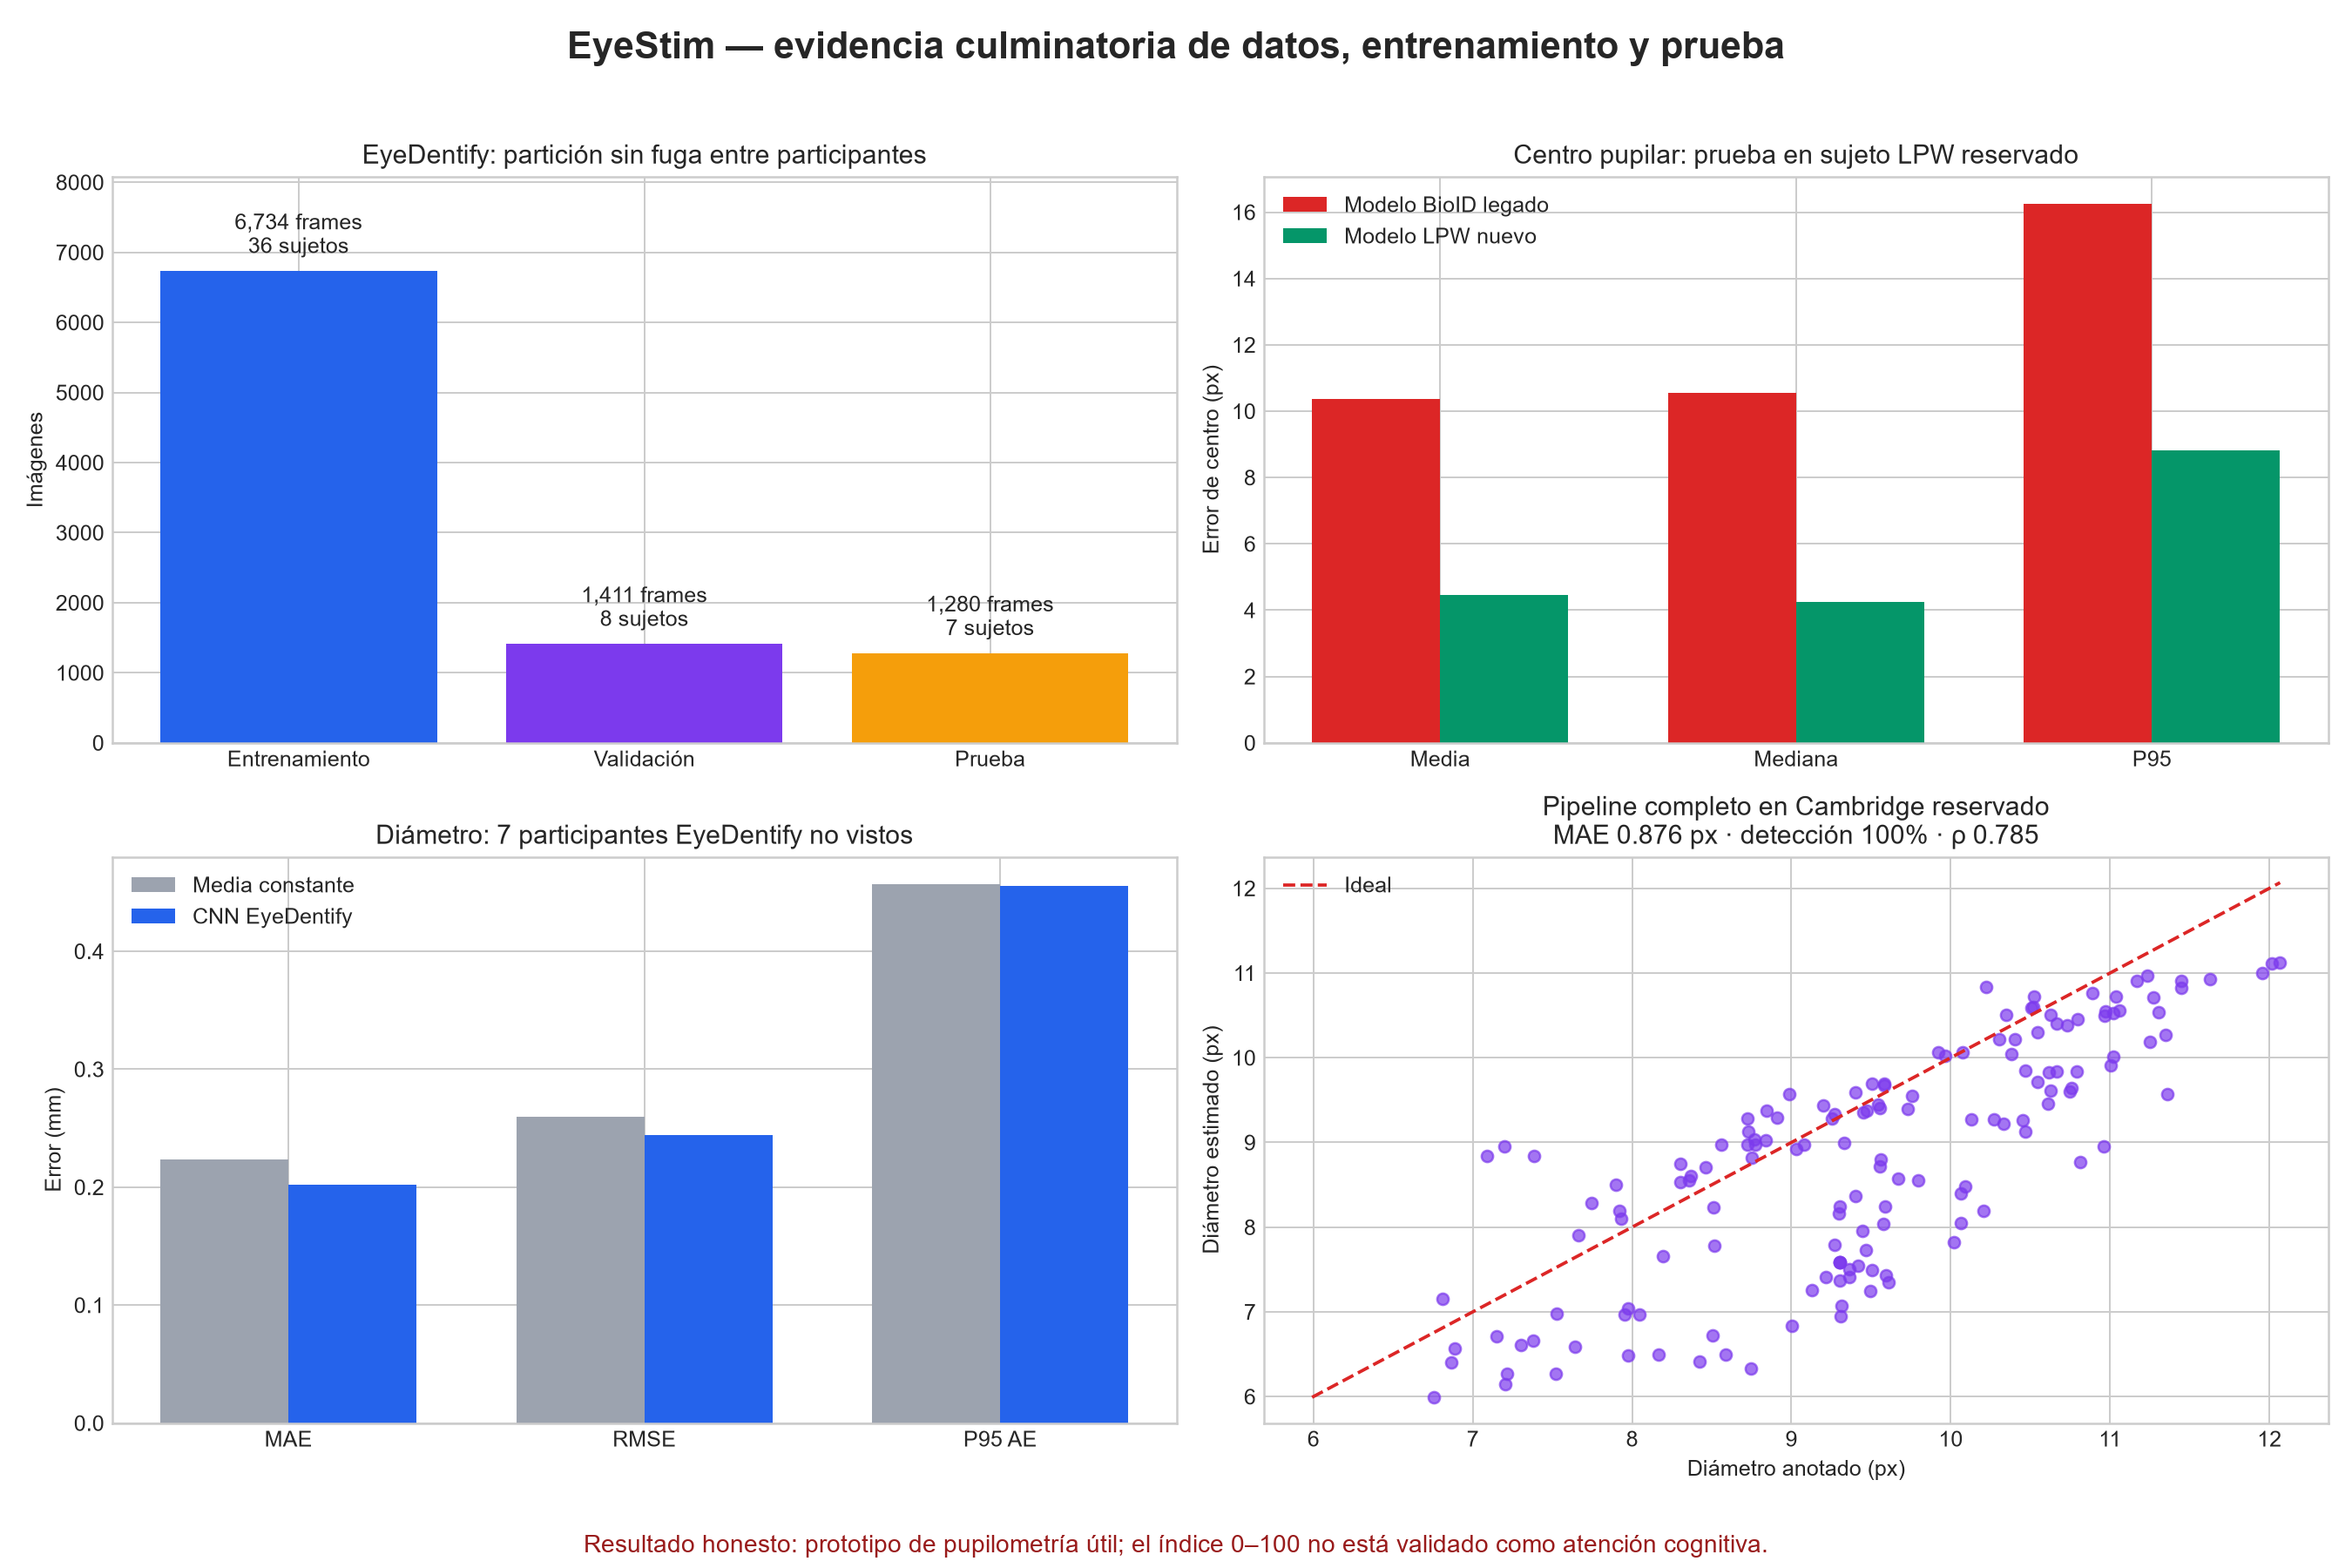

In [4]:
display(Image(filename=str(ROOT / 'docs' / 'training' / 'project_dashboard.png'), width=1100))

## Dictamen

Los nuevos datasets sí corresponden a los objetivos geométricos: LPW para centro pupilar y EyeDentify para diámetro con referencia Tobii. El resultado es un **prototipo experimental de pupilometría**, no un medidor clínico. El umbral de éxito declarado de 0.8 px aún no se cumple (0.876 px), y la investigación previa mostró que la fórmula 0–100 no valida atención cognitiva; por ello la interfaz la denomina índice ocular experimental.